# Stream Station Typology

Principal component analysis and k-means clustering of Massachusetts stream
monitoring stations from total-phosphorus, soil, and land-cover attributes.

**Training set:** 53 sites. The 11 held-out sites are classified in
`sst-validation.ipynb`.

Pipeline: **data input → correlation → PCA → clustering → characterization → save model.**

In [1]:
# --- Setup & configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Paths resolve whether the notebook runs from bin/ or the project root
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "bin" else ROOT
DATA = ROOT / "data" / "tidy" / "MA_Combined_streams_TP_soil_LULC_within_50m(in).csv"
OUT = ROOT / "results"
OUT.mkdir(exist_ok=True)

FEATURES = ["GMeanTP", "sen_slope", "TFACTOR", "AWS100", "AWS25", "DEP2WATTBL",
            "SLOPE_1", "CM2RESLYR", "KFACTWS", "PHWATER", "CLAY", "KSAT", "OM",
            "SAND", "Land_Cover_Encoded"]
ID_COLS = ["MonitoringLocationName", "Latitude", "Longitude"]
PC_NAMES = {"PC1": "Erodibility", "PC2": "Drainage", "PC3": "Eutrophication Potential"}

VARIABLE_LABELS = {
    "GMeanTP": "Geometric Mean TP (µg/L)",
    "sen_slope": "TP Sen Slope (µg/L)",
    "TFACTOR": "Soil Tolerance Factor",
    "AWS100": "Available Water Storage 0-100 cm",
    "AWS25": "Available Water Storage 0-25 cm",
    "DEP2WATTBL": "Depth to Water Table (cm)",
    "SLOPE_1": "Soil Slope",
    "CM2RESLYR": "Depth to Restrictive Layer (cm)",
    "KFACTWS": "Whole Soil Erodibility Factor",
    "PHWATER": "Soil pH",
    "CLAY": "Percent Clay",
    "KSAT": "Saturated Hydraulic Conductivity (in/hr)",
    "OM": "Percent Organic Matter",
    "SAND": "Percent Sand",
    "Land_Cover_Encoded": "Land Cover",
}

# 11 sites held out for validation
TEST_SITES = [
    "Doolittle Brook", "Eastman Brook Downstream", "Eastman Brook Upstream",
    "Horse Farm Brook Downstream", "Horse Farm Brook Upstream", "Knightly Brook",
    "Lake Warner Mill River", "Lake Warner Outlet", "Roaring Brook",
    "Tan Brook Downstream", "Tan Brook Upstream",
]

N_PCS_CLUSTER = 3      # cluster on the first 3 principal components
RANDOM_STATE = 45
PALETTE = list(plt.get_cmap("tab10").colors)

In [2]:
# --- Data input: encode land cover, hold out validation sites ---
df = pd.read_csv(DATA)

# Encode land cover from the full dataset so the mapping matches validation
lulc_mapping = {name: i for i, name in enumerate(sorted(df["Land_Cover"].unique()))}
df["Land_Cover_Encoded"] = df["Land_Cover"].map(lulc_mapping)

train = df[~df["MonitoringLocationName"].isin(TEST_SITES)].reset_index(drop=True)
train = train.dropna(subset=FEATURES)
X = train[FEATURES]

print(f"Training sites: {len(train)}   Features: {len(FEATURES)}   "
      f"Land-cover classes: {len(lulc_mapping)}")
train[ID_COLS + FEATURES].head()

Training sites: 53   Features: 15   Land-cover classes: 11


,MonitoringLocationName,Latitude,Longitude,GMeanTP,sen_slope,TFACTOR,AWS100,AWS25,DEP2WATTBL,SLOPE_1,CM2RESLYR,KFACTWS,PHWATER,CLAY,KSAT,OM,SAND,Land_Cover_Encoded
0,Assabet River,42.30,-71.63,106.3,-0.7,3,12.01,3.44,51,5,81,0.28,5.2,7.0,10.0000,7.01,61.0,1
1,Blackstone River,42.23,-71.79,100.5,-0.2,3,4.73,1.80,0,8,0,0.10,4.6,2.0,100.0000,2.80,81.0,4
2,Cady Brook,42.12,-72.01,26.5,-0.4,2,10.61,4.21,0,9,76,0.28,4.2,9.0,10.0001,10.00,58.0,8
3,"Central Cemetery, Millbury",42.19,-71.77,67.6,0.0,4,23.40,7.25,8,1,0,0.32,6.2,9.5,9.1700,15.00,64.1,1
4,Concord River,42.64,-71.30,62.4,-0.6,4,5.27,1.82,0,5,0,0.28,5.1,5.4,100.0000,4.12,60.1,4


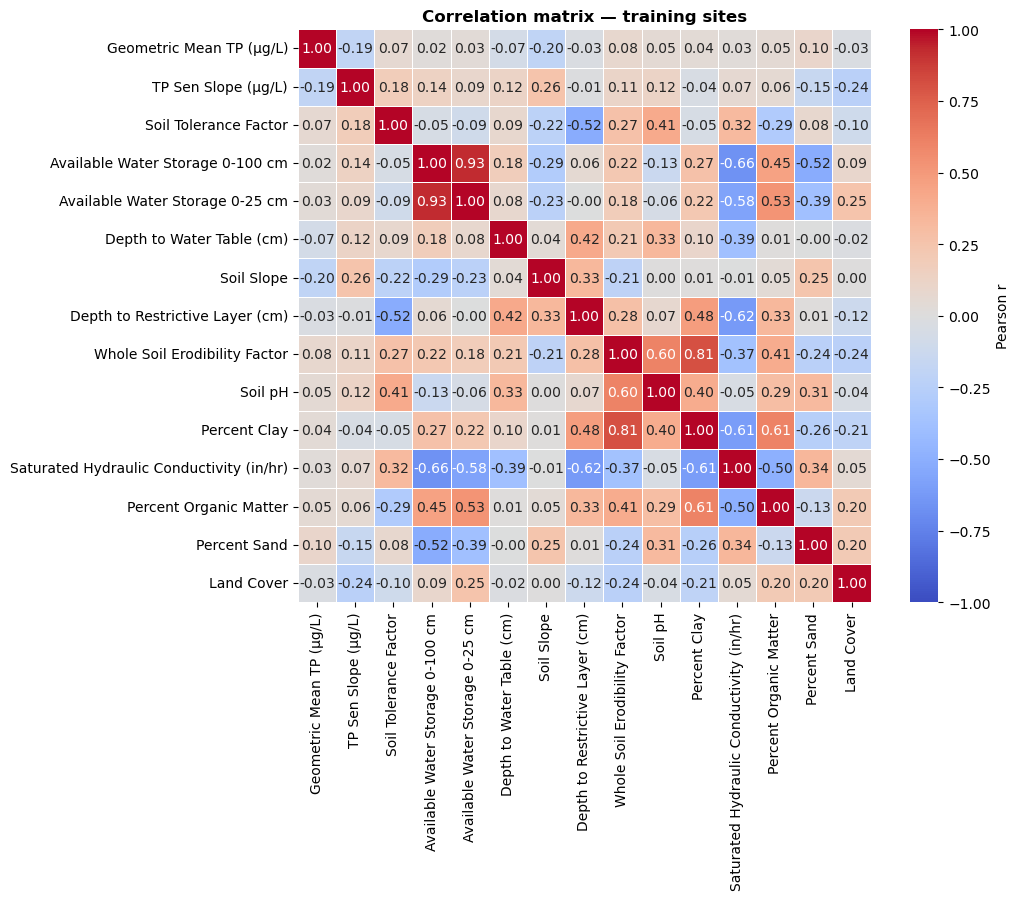

In [3]:
# --- Correlation analysis (optional; set RUN_CORRELATION = False to skip) ---
RUN_CORRELATION = True
if RUN_CORRELATION:
    corr = X.corr(method="pearson")
    labels = [VARIABLE_LABELS.get(c, c) for c in corr.columns]
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"label": "Pearson r"},
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title("Correlation matrix — training sites", fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT / "correlation_heatmap.png", dpi=200)
    corr.to_csv(OUT / "correlation_matrix.csv")
    plt.show()

In [4]:
# --- PCA ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA().fit(X_std)
scores = pca.transform(X_std)

# Loadings = correlation of each variable with each component
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=FEATURES,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])

variance = pd.DataFrame({
    "PC": loadings.columns,
    "Variance %": (pca.explained_variance_ratio_ * 100).round(2),
    "Cumulative %": (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
    "Eigenvalue": pca.explained_variance_.round(3),
})
n90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= .90) + 1)
print(f"PCs needed for 90% cumulative variance: {n90}\n")
print(variance.to_string(index=False))
loadings.iloc[:, :N_PCS_CLUSTER].round(3)

PCs needed for 90% cumulative variance: 8

  PC  Variance %  Cumulative %  Eigenvalue
 PC1       26.96         26.96       4.122
 PC2       15.45         42.41       2.361
 PC3       13.65         56.06       2.087
 PC4       10.15         66.20       1.551
 PC5        8.83         75.04       1.351
 PC6        7.38         82.41       1.128
 PC7        5.75         88.16       0.878
 PC8        3.24         91.40       0.495
 PC9        3.14         94.54       0.480
PC10        1.99         96.53       0.304
PC11        1.26         97.79       0.193
PC12        0.94         98.73       0.144
PC13        0.72         99.45       0.110
PC14        0.33         99.78       0.050
PC15        0.22        100.00       0.034


,PC1,PC2,PC3
GMeanTP,-0.018,0.036,0.217
sen_slope,-0.089,0.156,0.114
TFACTOR,0.193,0.385,0.766
AWS100,-0.742,-0.529,0.275
AWS25,-0.691,-0.544,0.254
DEP2WATTBL,-0.344,0.310,-0.126
SLOPE_1,0.107,0.237,-0.672
CM2RESLYR,-0.531,0.265,-0.710
KFACTWS,-0.663,0.555,0.339
PHWATER,-0.255,0.786,0.265


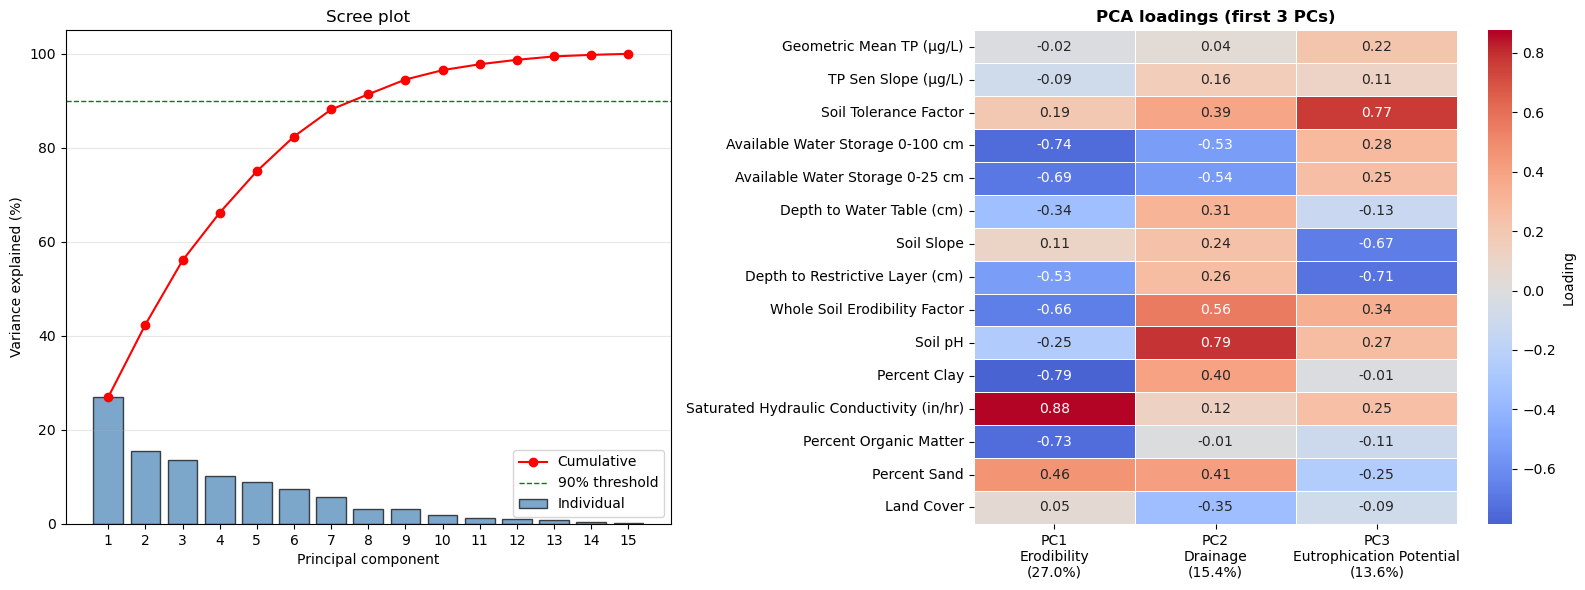

In [5]:
# --- PCA visualization: scree plot + loadings heatmap ---
pcs = np.arange(1, pca.n_components_ + 1)
vpct = pca.explained_variance_ratio_ * 100
cum = np.cumsum(vpct)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(pcs, vpct, color="steelblue", edgecolor="black", alpha=.7, label="Individual")
axes[0].plot(pcs, cum, "ro-", label="Cumulative")
axes[0].axhline(90, color="green", ls="--", lw=1, label="90% threshold")
axes[0].set(xlabel="Principal component", ylabel="Variance explained (%)", title="Scree plot")
axes[0].set_xticks(pcs)
axes[0].legend()
axes[0].grid(axis="y", alpha=.3)

disp = loadings.iloc[:, :N_PCS_CLUSTER].copy()
disp.index = [VARIABLE_LABELS.get(f, f) for f in disp.index]
disp.columns = [f"{c}\n{PC_NAMES.get(c, '')}\n({v:.1f}%)"
                for c, v in zip(disp.columns, vpct)]
sns.heatmap(disp, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=.5,
            cbar_kws={"label": "Loading"}, ax=axes[1])
axes[1].set_title("PCA loadings (first 3 PCs)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "pca_overview.png", dpi=200)
plt.show()

In [6]:
# --- Clustering: pick k by silhouette, fit k-means on the first 3 PCs ---
Z = scores[:, :N_PCS_CLUSTER]

sil = {k: silhouette_score(Z, KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Z))
       for k in range(2, 11)}
best_k = max(sil, key=sil.get)
print("Silhouette by k:", {k: round(s, 3) for k, s in sil.items()})
print(f"Best k = {best_k} (silhouette {sil[best_k]:.3f})\n")

kmeans = KMeans(best_k, random_state=RANDOM_STATE, n_init=10).fit(Z)
train["Cluster"] = kmeans.labels_
print("Cluster sizes:")
print(train["Cluster"].value_counts().sort_index().to_string())

Silhouette by k: {2: 0.416, 3: 0.477, 4: 0.497, 5: 0.519, 6: 0.525, 7: 0.472, 8: 0.48, 9: 0.452, 10: 0.401}
Best k = 6 (silhouette 0.525)

Cluster sizes:
Cluster
0     8
1     7
2     1
3    16
4    17
5     4


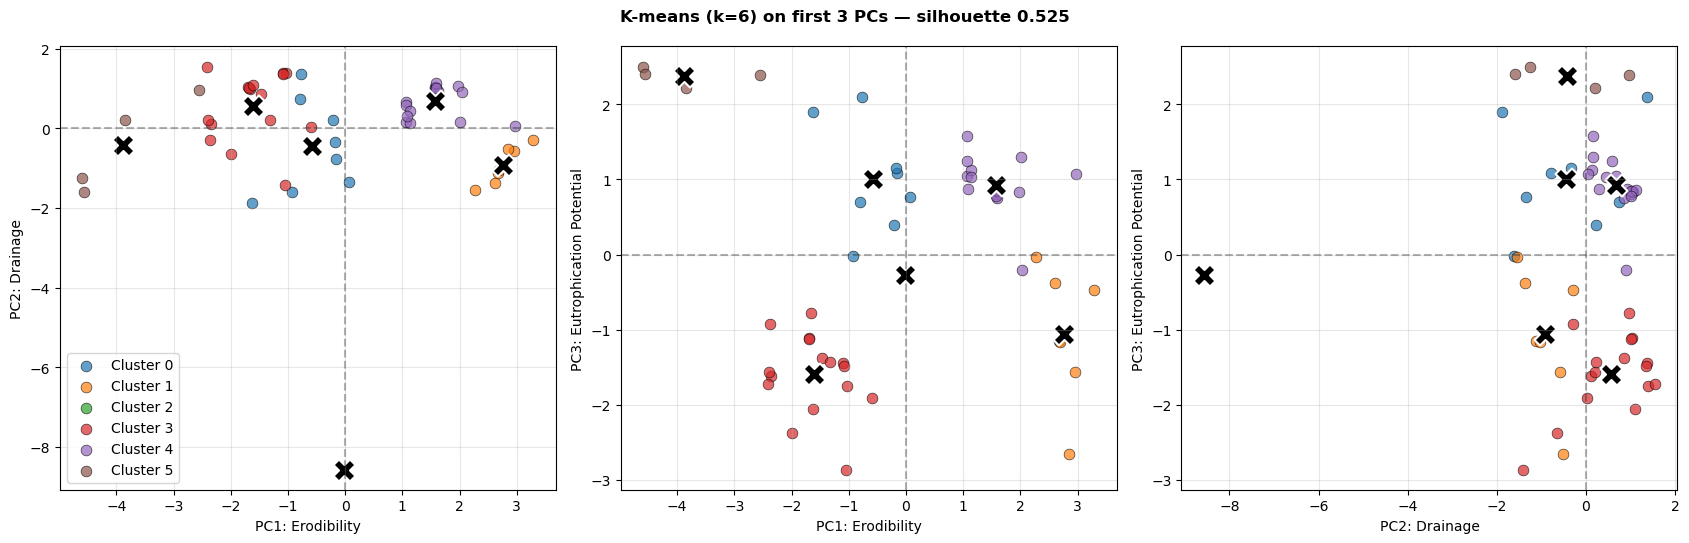

In [7]:
# --- Cluster visualization in PC space ---
centers = kmeans.cluster_centers_
pairs = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (a, b) in zip(axes, pairs):
    for c in range(best_k):
        m = kmeans.labels_ == c
        ax.scatter(Z[m, a], Z[m, b], c=[PALETTE[c]], s=60, alpha=.7,
                   edgecolors="black", linewidth=.5, label=f"Cluster {c}")
    ax.scatter(centers[:, a], centers[:, b], c="black", marker="X", s=250,
               edgecolors="white", linewidth=1.5)
    ax.axhline(0, color="k", ls="--", alpha=.3)
    ax.axvline(0, color="k", ls="--", alpha=.3)
    ax.set(xlabel=f"PC{a+1}: {PC_NAMES[f'PC{a+1}']}",
           ylabel=f"PC{b+1}: {PC_NAMES[f'PC{b+1}']}")
    ax.grid(alpha=.3)
axes[0].legend()
fig.suptitle(f"K-means (k={best_k}) on first {N_PCS_CLUSTER} PCs — "
             f"silhouette {sil[best_k]:.3f}", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "clusters_pca.png", dpi=200)
plt.show()

In [8]:
# --- Cluster characterization ---
profile = train.groupby("Cluster")[FEATURES].mean().T
profile.index = [VARIABLE_LABELS.get(f, f) for f in profile.index]
print("Mean feature profile per cluster:")
print(profile.round(2).to_string())

print("\nLand cover by cluster:")
print(pd.crosstab(train["Cluster"], train["Land_Cover"]).to_string())

Mean feature profile per cluster:
Cluster                                       0      1      2      3      4      5
Geometric Mean TP (µg/L)                  47.19  41.06  30.80  43.36  46.78  43.62
TP Sen Slope (µg/L)                       -0.41  -0.17   0.00  -0.26  -0.17   0.12
Soil Tolerance Factor                      3.88   3.00   2.00   2.81   4.24   4.25
Available Water Storage 0-100 cm          14.42   6.17  30.23  11.46   7.31  22.82
Available Water Storage 0-25 cm            4.93   2.52   7.81   3.66   2.52   6.88
Depth to Water Table (cm)                 16.88   0.00   0.00  45.81  12.76  40.25
Soil Slope                                 3.38  12.00   0.00  10.31   5.41   1.25
Depth to Restrictive Layer (cm)            0.00   0.00   0.00  69.31   0.00   0.00
Whole Soil Erodibility Factor              0.25   0.09   0.00   0.28   0.25   0.36
Soil pH                                    5.45   4.63   0.00   5.12   5.12   5.78
Percent Clay                               5.38   2.1

In [9]:
# --- Save the labeled typology and the fitted model bundle ---
train[ID_COLS + FEATURES + ["Cluster"]].to_csv(
    OUT / "typology_training_labeled.csv", index=False)

joblib.dump({
    "scaler": scaler, "pca": pca, "kmeans": kmeans,
    "features": FEATURES, "id_cols": ID_COLS, "lulc_mapping": lulc_mapping,
    "pc_names": PC_NAMES, "variable_labels": VARIABLE_LABELS,
    "n_pcs_cluster": N_PCS_CLUSTER, "test_sites": TEST_SITES,
    "train_scores": Z, "train_labels": kmeans.labels_,
}, OUT / "typology_model.joblib")
print("Saved typology_training_labeled.csv and typology_model.joblib to", OUT)

Saved typology_training_labeled.csv and typology_model.joblib to /home/jbo/Projects/stream-station-typology/results
